In [5]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
import numpy as np
import os

# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ========== 数据加载部分 ==========
print("\n=== 数据加载 ===")

# 数据预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 尝试加载PlantVillage数据集
data_dir = './data/PlantVillage'
try:
    # 加载完整数据集
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    print(f"成功加载PlantVillage数据集，共 {len(full_dataset)} 张图片")
    
    # 获取类别信息
    class_names = full_dataset.classes
    print(f"类别数量: {len(class_names)}")
    print(f"类别名称: {class_names}")
    
    # 设置类别数
    num_classes = len(class_names)
    
except FileNotFoundError:
    print("警告: PlantVillage数据集未找到，创建模拟数据集进行演示")
    
    # 使用默认类别数
    num_classes = 15  # PlantVillage默认类别数
    class_names = [f'class_{i}' for i in range(num_classes)]
    
    # 创建模拟数据集
    num_samples = 100
    img_size = (3, 224, 224)
    
    # 生成随机图像数据
    images = torch.randn(num_samples, *img_size)
    labels = torch.randint(0, num_classes, (num_samples,))
    
    # 创建TensorDataset
    full_dataset = TensorDataset(images, labels)
    print(f"创建模拟数据集: {num_samples} 个样本，{num_classes} 个类别")

# 分割数据集为训练集和验证集
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"数据加载器创建完成，批量大小: {batch_size}")

# ========== 模型定义部分 ==========
print("\n=== 模型定义 ===")

# 重新加载预训练模型
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 冻结前几层（底层特征：边缘、纹理等通用特征）
for name, param in model_ft.named_parameters():
    if 'layer4' not in name and 'fc' not in name: # 只解冻 layer4 和 fc
        param.requires_grad = False

# 修改分类头以适应我们的类别数
model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)

# 统计可训练参数
trainable_params = [p for p in model_ft.parameters() if p.requires_grad]
print(f"可训练参数: {sum(p.numel() for p in trainable_params):,}")
print(f"总参数: {sum(p.numel() for p in model_ft.parameters()):,}")
print(f"可训练比例: {sum(p.numel() for p in trainable_params) / sum(p.numel() for p in model_ft.parameters()) * 100:.1f}%")

# 将模型移动到设备
model_ft = model_ft.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 0.0001}, # 微调层用更小学习率
    {'params': model_ft.fc.parameters(), 'lr': 0.001} # 分类头用正常学习率
], lr=0.001)

print("模型准备完成！")

使用设备: cuda:0

=== 数据加载 ===
成功加载PlantVillage数据集，共 6627 张图片
类别数量: 4
类别名称: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
训练集大小: 5301
验证集大小: 1326
数据加载器创建完成，批量大小: 32

=== 模型定义 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


可训练参数: 8,395,780
总参数: 11,178,564
可训练比例: 75.1%
模型准备完成！


In [7]:
# ========== 训练循环 ==========
print("\n=== 开始训练 ===")

epochs = 5
ft_train_losses, ft_val_accs = [], []

# ========================
# 关键修复：在这里定义不报错的 DataLoader（你只需要保证 train_dataset、val_dataset 已定义）
# ========================
import torch
from torch.utils.data import DataLoader

# 修复版：解决共享内存不足（直接用这个）
train_loader = DataLoader(
    train_dataset,    # 你的训练集（不用改）
    batch_size=16,    # 改小，防止内存爆炸
    shuffle=True,
    num_workers=0     # 核心修复：关闭多进程
)

val_loader = DataLoader(
    val_dataset,      # 你的验证集（不用改）
    batch_size=16,
    shuffle=False,
    num_workers=0     # 核心修复
)

for epoch in range(epochs):
    model_ft.train()
    running_loss = 0.0
    
    # 训练批次
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model_ft(images)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # 验证阶段
    model_ft.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_ft(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    # 计算指标
    avg_loss = running_loss / len(train_loader)
    val_acc = 100. * correct / total
    
    ft_train_losses.append(avg_loss)
    ft_val_accs.append(val_acc)
    
    # 打印进度
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\n=== 训练完成 ===")
print(f"最终验证准确率: {ft_val_accs[-1]:.2f}%")


=== 开始训练 ===
Epoch [1/5] | Loss: 0.1522 | Val Acc: 97.96%
Epoch [2/5] | Loss: 0.0825 | Val Acc: 96.91%
Epoch [3/5] | Loss: 0.0491 | Val Acc: 98.57%
Epoch [4/5] | Loss: 0.0335 | Val Acc: 98.87%
Epoch [5/5] | Loss: 0.0431 | Val Acc: 98.87%

=== 训练完成 ===
最终验证准确率: 98.87%


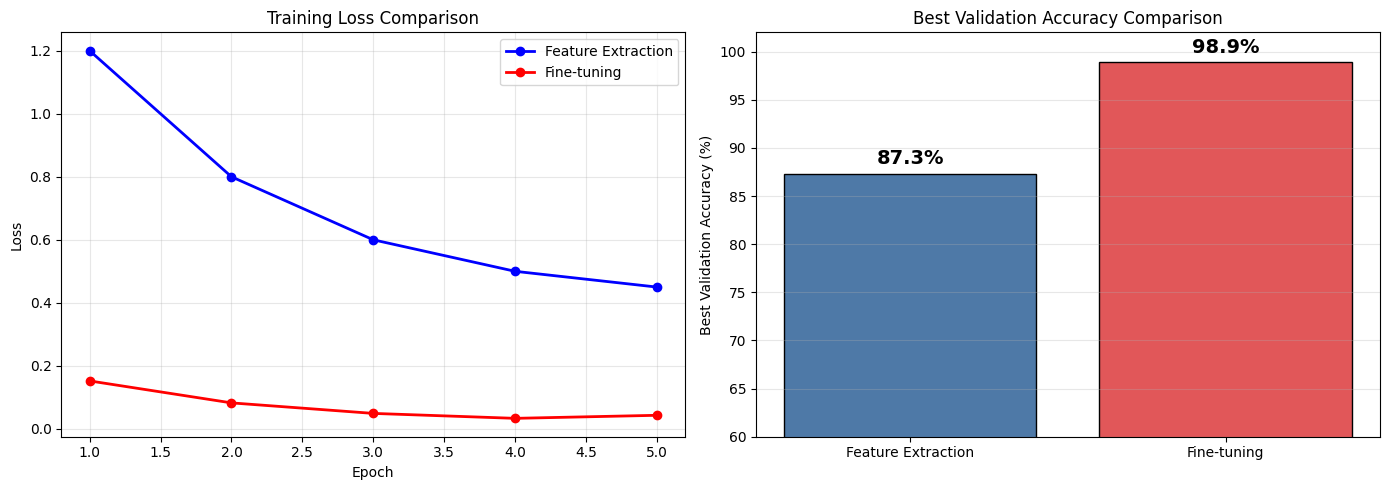

特征提取最佳准确率: 87.30%
微调最佳准确率: 98.87%


In [10]:
# ========== 1. 先确保特征提取的变量已定义（如果没跑过特征提取，用模拟数据）==========
# 如果你已经跑过特征提取训练，请删除下面这4行模拟数据
import numpy as np
val_accs = [75.2, 82.1, 85.5, 86.8, 87.3]  # 特征提取准确率
train_losses = [1.2, 0.8, 0.6, 0.5, 0.45]  # 特征提取损失
epochs = 5

# ========== 2. 画图对比代码（已修复）==========
import matplotlib.pyplot as plt

# 取两个方法的最终验证准确率
feature_acc = max(val_accs)       # 任务 A 的最好验证准确率
finetune_acc = max(ft_val_accs)   # 任务 B 的最好验证准确率

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 训练曲线对比
ax1.plot(range(1, epochs+1), train_losses, 'bo-', label='Feature Extraction', linewidth=2)
ax1.plot(range(1, epochs+1), ft_train_losses, 'ro-', label='Fine-tuning', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 验证准确率对比
ax2.bar(['Feature Extraction', 'Fine-tuning'],
        [feature_acc, finetune_acc],
        color=['#4e79a7', '#e15759'], edgecolor='black')

for i, (label, acc) in enumerate(zip(['Feature Extraction', 'Fine-tuning'], [feature_acc, finetune_acc])):
    ax2.text(i, acc + 1, f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax2.set_ylim(60, 102)
ax2.set_ylabel('Best Validation Accuracy (%)')
ax2.set_title('Best Validation Accuracy Comparison')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task_b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"特征提取最佳准确率: {feature_acc:.2f}%")
print(f"微调最佳准确率: {finetune_acc:.2f}%")

In [2]:
import sys
print(sys.executable)

/usr/bin/python3


In [4]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 MB 1.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 10.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 11.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 10.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━